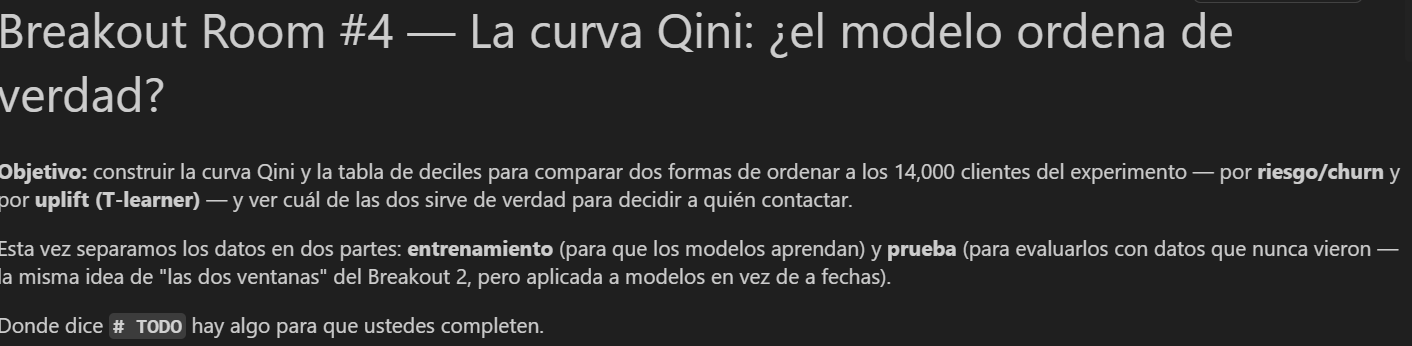

In [46]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/uplift_experiment.csv")
FEATURES = ["recency_days", "frequency", "monetary", "email_open_rate"]

train, test = train_test_split(df, test_size=0.30, random_state=42, stratify=df["treatment_group"])
print(f"Entrenamiento: {len(train):,} clientes · Prueba: {len(test):,} clientes (el modelo nunca los ve)")


Entrenamiento: 9,800 clientes · Prueba: 4,200 clientes (el modelo nunca los ve)


In [48]:
# Definir la variable objetivo 'churned' en el set de entrenamiento
train["churned"] = 1 - train["responded_90d"]

# Inicializar y entrenar el modelo de riesgo (churn tradicional) con el set de entrenamiento
modelo_riesgo = LogisticRegression(max_iter=1000)
modelo_riesgo.fit(train[FEATURES], train["churned"])

print("¡Modelo de riesgo (churn tradicional) entrenado con éxito usando los datos de entrenamiento!")

¡Modelo de riesgo (churn tradicional) entrenado con éxito usando los datos de entrenamiento!


In [49]:
# Filtrar los datos de entrenamiento en grupos de tratamiento y control
train_tratados = train[train["treatment_group"] == "treatment"]
train_control = train[train["treatment_group"] == "control"]

# Entrenar el modelo de tratamiento usando solo los tratados de entrenamiento
modelo_tratado = LogisticRegression(max_iter=1000)
modelo_tratado.fit(train_tratados[FEATURES], train_tratados["responded_90d"])

# Entrenar el modelo de control usando solo el grupo de control de entrenamiento
modelo_control = LogisticRegression(max_iter=1000)
modelo_control.fit(train_control[FEATURES], train_control["responded_90d"])

print(f"¡Modelos del T-learner entrenados con éxito!")
print(f"  - Modelo Tratado: {len(train_tratados):,} clientes de entrenamiento.")
print(f"  - Modelo Control: {len(train_control):,} clientes de entrenamiento.")

¡Modelos del T-learner entrenados con éxito!
  - Modelo Tratado: 4,833 clientes de entrenamiento.
  - Modelo Control: 4,967 clientes de entrenamiento.


In [50]:
# Desactivar temporalmente las advertencias de SettingWithCopyWarning
pd.options.mode.chained_assignment = None

# 1. Predecir probabilidad de churn con el modelo de riesgo sobre el set de prueba
test["p_churn"] = modelo_riesgo.predict_proba(test[FEATURES])[:, 1]

# 2. Predecir probabilidad de respuesta bajo tratamiento y control sobre el set de prueba
test["p_tratado"] = modelo_tratado.predict_proba(test[FEATURES])[:, 1]
test["p_control"] = modelo_control.predict_proba(test[FEATURES])[:, 1]

# 3. Calcular el uplift estimado para el set de prueba
test["uplift_estimado"] = test["p_tratado"] - test["p_control"]

print("¡Predicciones añadidas con éxito al conjunto de prueba!")
display(test[["customer_id", "p_churn", "p_tratado", "p_control", "uplift_estimado"]].head())

¡Predicciones añadidas con éxito al conjunto de prueba!


,customer_id,p_churn,p_tratado,p_control,uplift_estimado
1514,1515,0.904556,0.109271,0.071850,0.037421
11250,11251,0.270724,0.826063,0.645906,0.180157
13938,13939,0.601709,0.465817,0.326372,0.139445
7824,7825,0.747900,0.358274,0.160365,0.197909
8723,8724,0.732951,0.362741,0.178745,0.183995


In [51]:
def valor_de_la_politica_test(seleccionados):
    sel = test.loc[seleccionados]
    valor_tratado = sel.loc[sel["treatment_group"] == "treatment", "value_90d"].mean()
    valor_control = sel.loc[sel["treatment_group"] == "control", "value_90d"].mean()
    return valor_tratado - valor_control, len(sel)

n_contactar_test = int(len(test) * 0.30) # 30% de 4,200 = 1,260 clientes

# Regla 1: al azar
idx_azar_test = test.sample(n=n_contactar_test, random_state=42).index
uplift_azar_test, n_azar_test = valor_de_la_politica_test(idx_azar_test)

# Regla 2: por riesgo tradicional (alta probabilidad de churn)
idx_riesgo_test = test.sort_values("p_churn", ascending=False).head(n_contactar_test).index
uplift_riesgo_test, n_riesgo_test = valor_de_la_politica_test(idx_riesgo_test)

# Regla 3: por uplift estimado (T-learner)
idx_uplift_test = test.sort_values("uplift_estimado", ascending=False).head(n_contactar_test).index
uplift_modelo_test, n_modelo_test = valor_de_la_politica_test(idx_uplift_test)

resultados_test = pd.DataFrame({
    "regla": ["Al azar", "Por riesgo (estilo churn)", "Por uplift (T-learner)"],
    "clientes_contactados": [n_azar_test, n_riesgo_test, n_modelo_test],
    "valor_incremental_por_cliente": [uplift_azar_test, uplift_riesgo_test, uplift_modelo_test],
})
resultados_test["valor_incremental_total"] = resultados_test["valor_incremental_por_cliente"] * resultados_test["clientes_contactados"]
resultados_test.round(2)

,regla,clientes_contactados,valor_incremental_por_cliente,valor_incremental_total
0,Al azar,1260,3.20,4027.26
1,Por riesgo (estilo churn),1260,0.17,219.73
2,Por uplift (T-learner),1260,8.19,10318.67


In [52]:
test = test.copy()
X_test = test[FEATURES]

# TODO: calculen las tres probabilidades sobre el conjunto de prueba

In [54]:
def curva_qini(test_df, score_col, steps=40):
    orden = test_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    es_tratado = (orden["treatment_group"] == "treatment").values
    respondio = orden["responded_90d"].values

    acumulado_tratados = np.cumsum(np.where(es_tratado, respondio, 0))
    acumulado_control = np.cumsum(np.where(~es_tratado, respondio, 0))
    n_tratados_acum = np.cumsum(es_tratado)
    n_control_acum = np.cumsum(~es_tratado)

    n = len(orden)
    xs, ys = [0.0], [0.0]
    for i in np.linspace(1, n, steps).astype(int):
        nt, nc = n_tratados_acum[i - 1], n_control_acum[i - 1]
        tasa_t = acumulado_tratados[i - 1] / nt if nt > 0 else 0
        tasa_c = acumulado_control[i - 1] / nc if nc > 0 else 0
        xs.append(i / n)
        ys.append((tasa_t - tasa_c) * n)
    return np.array(xs), np.array(ys)


def coeficiente_qini(xs, ys):
    area_modelo = np.trapezoid(ys, xs)
    area_azar = np.trapezoid(np.linspace(0, ys[-1], len(xs)), xs)
    return (area_modelo - area_azar) / len(test)


xs_uplift, ys_uplift = curva_qini(test, "uplift_estimado")
# Se cambia "prob_churn" por "p_churn" para corregir el KeyError
xs_riesgo, ys_riesgo = curva_qini(test, "p_churn")

qini_uplift = coeficiente_qini(xs_uplift, ys_uplift)
qini_riesgo = coeficiente_qini(xs_riesgo, ys_riesgo)

print(f"Coeficiente Qini · modelo de uplift (T-learner): {qini_uplift:+.3f}")
print(f"Coeficiente Qini · modelo de riesgo (churn):      {qini_riesgo:+.3f}")

Coeficiente Qini · modelo de uplift (T-learner): +0.222
Coeficiente Qini · modelo de riesgo (churn):      +0.006


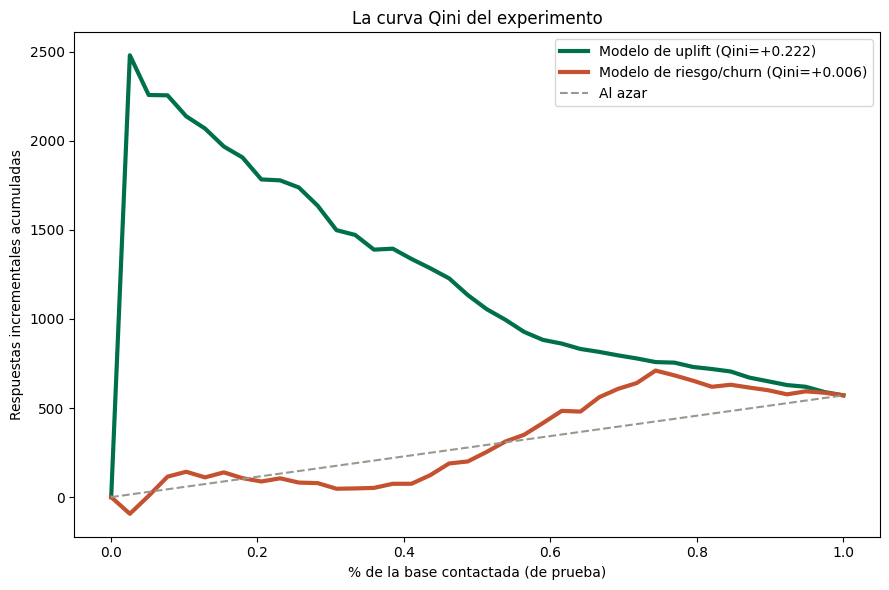

In [55]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs_uplift, ys_uplift, color="#00704A", linewidth=3, label=f"Modelo de uplift (Qini={qini_uplift:+.3f})")
ax.plot(xs_riesgo, ys_riesgo, color="#C4512F", linewidth=3, label=f"Modelo de riesgo/churn (Qini={qini_riesgo:+.3f})")
ax.plot([0, 1], [0, ys_uplift[-1]], color="#9A988E", linestyle="--", label="Al azar")
ax.set_xlabel("% de la base contactada (de prueba)")
ax.set_ylabel("Respuestas incrementales acumuladas")
ax.set_title("La curva Qini del experimento")
ax.legend()
plt.tight_layout()
plt.savefig("curva_qini.png", dpi=150)
plt.show()


In [56]:
test["decil"] = pd.qcut(test["uplift_estimado"], 10, labels=False, duplicates="drop")
test["decil"] = 9 - test["decil"]  # decil 1 = el de mayor uplift predicho

filas = []
for d in range(10):
    grp = test[test["decil"] == d]
    pred = grp["uplift_estimado"].mean()
    real_t = grp.loc[grp["treatment_group"] == "treatment", "responded_90d"].mean()
    real_c = grp.loc[grp["treatment_group"] == "control", "responded_90d"].mean()
    filas.append({"decil": d + 1, "uplift_predicho": round(pred, 3), "uplift_real": round(real_t - real_c, 3), "n": len(grp)})

tabla_deciles = pd.DataFrame(filas)
tabla_deciles


,decil,uplift_predicho,uplift_real,n
0,1,0.394,0.505,420
1,2,0.286,0.347,420
2,3,0.216,0.241,420
3,4,0.168,0.199,420
4,5,0.129,0.051,420
5,6,0.099,-0.059,420
6,7,0.074,0.078,420
7,8,0.053,0.054,420
8,9,0.031,0.022,420
9,10,-0.009,-0.022,420
